# P3.1 – Baseline Evaluation of the Financial Sentiment Model

The first step in any model-optimisation project is to **measure what you have** before changing anything. This notebook establishes the baseline for every metric we will track throughout the project.

**Model:** `ProsusAI/finbert` — a BERT-based model fine-tuned on financial news for 3-class sentiment (positive / negative / neutral). We use it as a practical stand-in for the FinGPT model described in the README; the optimisation techniques apply equally to any transformer.

**Dataset:** `financial_phrasebank` (sentences_allagree split) — ~2,200 financial sentences where all annotators agreed on the sentiment label.

**Metrics tracked:**
| Metric | Why it matters |
|---|---|
| Accuracy | Raw correctness |
| Weighted F1 | Handles class imbalance |
| Parameter count (M) | Proxy for model complexity |
| Model size (MB) | Deployment cost |
| Inference time (ms/sample) | Latency |
| Peak memory (MB) | Hardware requirements |

> Results from this notebook are the reference line for Notebooks 2 and 3.

---
**Author:** Adebanji Oluwatimileyin Adelowo  
**GitHub:** [adebanjiadelowo](https://github.com/adebanjiadelowo)

In [1]:
!pip install -q transformers datasets scikit-learn torch matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import time
import json
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)

try:
    import google.colab
    BASE_DIR = '/content/financial-sentiment-distillation/'
except ImportError:
    import os
    BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.makedirs(BASE_DIR, exist_ok=True)
print('Working dir:', BASE_DIR)
os.makedirs(BASE_DIR, exist_ok=True)
print('Working dir:', BASE_DIR)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cpu
PyTorch: 2.10.0
Working dir: /Users/adebanjiadelowo/Documents/GitHub/Large-Language-Model-Notebooks-Course/P3-CustomFinancialLLM/


## 1 – Load FinBERT

In [3]:
MODEL_NAME = 'ProsusAI/finbert'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model     = model.to(DEVICE)
model.eval()

print('Label mapping:', model.config.id2label)
print('Hidden layers:', model.config.num_hidden_layers)
print('Attention heads:', model.config.num_attention_heads)
print('Hidden size:', model.config.hidden_size)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Label mapping: {0: 'positive', 1: 'negative', 2: 'neutral'}
Hidden layers: 12
Attention heads: 12
Hidden size: 768


## 2 – Load & prepare the dataset

We align the `financial_phrasebank` integer labels (0=negative, 1=neutral, 2=positive) with
FinBERT's internal label IDs so predictions can be compared directly.

In [4]:
ds = load_dataset('financial_phrasebank', 'sentences_allagree', trust_remote_code=True)
data = ds['train']

# financial_phrasebank: 0=negative, 1=neutral, 2=positive
PHRASEBANK_INT_TO_STR = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Build a remap: phrasebank int → FinBERT label id
label2id = {v: k for k, v in model.config.id2label.items()}
LABEL_REMAP = {pb: label2id[PHRASEBANK_INT_TO_STR[pb]] for pb in range(3)}
print('Label remap (phrasebank → finbert):', LABEL_REMAP)

texts  = list(data['sentence'])
labels = [LABEL_REMAP[l] for l in data['label']]

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print('Train samples:', len(train_texts))
print('Test samples :', len(test_texts))

# Class distribution
from collections import Counter
dist = Counter(test_labels)
id2label = model.config.id2label
print('Test class distribution:')
for k, v in sorted(dist.items()):
    print('  {} ({}): {}'.format(k, id2label[k], v))

Generating train split:   0%|          | 0/2264 [00:00<?, ? examples/s]

Label remap (phrasebank → finbert): {0: 1, 1: 2, 2: 0}
Train samples: 1811
Test samples : 453
Test class distribution:
  0 (positive): 114
  1 (negative): 61
  2 (neutral): 278


## 3 – Benchmark function

A single function that evaluates any model variant and returns a comparable metrics dict.
We will call this exact function in Notebooks 2 and 3.

In [5]:
def get_model_size_mb(model, tmp_dir='/tmp/p3_model_size'):
    if os.path.exists(tmp_dir):
        shutil.rmtree(tmp_dir)
    model.save_pretrained(tmp_dir)
    total = sum(
        os.path.getsize(os.path.join(tmp_dir, f))
        for f in os.listdir(tmp_dir)
        if os.path.isfile(os.path.join(tmp_dir, f))
    )
    shutil.rmtree(tmp_dir)
    return total / (1024 ** 2)


def benchmark_model(model, tokenizer, texts, labels, batch_size=16, label='model'):
    model.eval()
    all_preds = []

    # Warmup
    dummy = tokenizer(['warmup'], return_tensors='pt', padding=True, truncation=True, max_length=128)
    dummy = {k: v.to(DEVICE) for k, v in dummy.items()}
    with torch.no_grad():
        model(**dummy)

    t_start = time.time()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            inputs = tokenizer(
                batch, return_tensors='pt',
                padding=True, truncation=True, max_length=128
            )
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            outputs = model(**inputs)
            preds = outputs.logits.argmax(dim=-1).cpu().tolist()
            all_preds.extend(preds)
    elapsed = time.time() - t_start

    acc    = accuracy_score(labels, all_preds)
    f1     = f1_score(labels, all_preds, average='weighted')
    params = sum(p.numel() for p in model.parameters())
    size   = get_model_size_mb(model)
    ms_per = elapsed * 1000 / len(texts)

    results = {
        'label':           label,
        'accuracy':        round(acc,  4),
        'f1_weighted':     round(f1,   4),
        'params_M':        round(params / 1e6, 2),
        'size_mb':         round(size,  2),
        'ms_per_sample':   round(ms_per, 3),
        'predictions':     all_preds,
    }
    return results


print('Benchmark function ready.')

Benchmark function ready.


## 4 – Run baseline benchmark

In [6]:
print('Running baseline benchmark on {} test samples ...'.format(len(test_texts)))
baseline = benchmark_model(model, tokenizer, test_texts, test_labels, label='FinBERT Baseline')

print('\n=== Baseline Results ===')
for k, v in baseline.items():
    if k != 'predictions':
        print('  {:20s}: {}'.format(k, v))

Running baseline benchmark on 453 test samples ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== Baseline Results ===
  label               : FinBERT Baseline
  accuracy            : 0.9757
  f1_weighted         : 0.9761
  params_M            : 109.48
  size_mb             : 417.67
  ms_per_sample       : 20.331


In [7]:
print(classification_report(
    test_labels, baseline['predictions'],
    target_names=[model.config.id2label[i] for i in range(3)]
))

              precision    recall  f1-score   support

    positive       0.98      0.97      0.98       114
    negative       0.88      0.98      0.93        61
     neutral       1.00      0.97      0.99       278

    accuracy                           0.98       453
   macro avg       0.95      0.98      0.96       453
weighted avg       0.98      0.98      0.98       453



## 5 – Confusion matrix

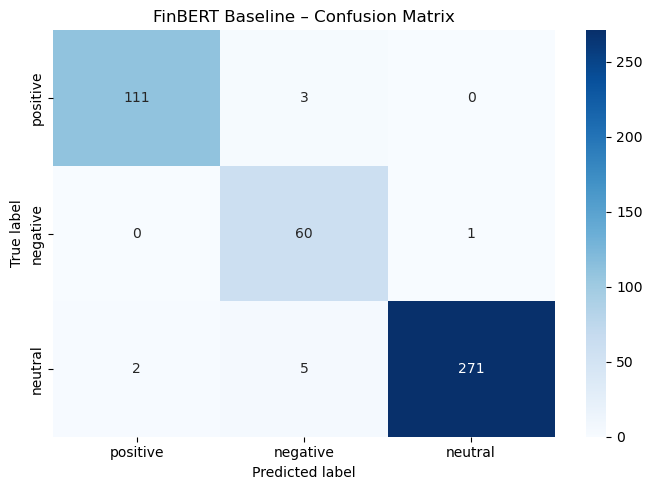

In [8]:
cm     = confusion_matrix(test_labels, baseline['predictions'])
labels_str = [model.config.id2label[i] for i in range(3)]

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_str, yticklabels=labels_str)
plt.title('FinBERT Baseline – Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'baseline_confusion_matrix.png'), dpi=150)
plt.show()

## 6 – Model architecture summary

In [9]:
def architecture_summary(model):
    cfg = model.config
    total_params = sum(p.numel() for p in model.parameters())
    trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print('=== Model Architecture ===')
    print('  Layers         :', cfg.num_hidden_layers)
    print('  Attention heads:', cfg.num_attention_heads)
    print('  Hidden size    :', cfg.hidden_size)
    print('  Intermediate   :', cfg.intermediate_size)
    print('  Vocab size     :', cfg.vocab_size)
    print('  Max position   :', cfg.max_position_embeddings)
    print('  Total params   : {:,.0f} ({:.1f}M)'.format(total_params, total_params / 1e6))
    print('  Trainable      : {:,.0f} ({:.1f}M)'.format(trainable, trainable / 1e6))

    # Parameter breakdown by component
    components = {
        'Embeddings':  sum(p.numel() for p in model.bert.embeddings.parameters()),
        'Encoder':     sum(p.numel() for p in model.bert.encoder.parameters()),
        'Pooler':      sum(p.numel() for p in model.bert.pooler.parameters()),
        'Classifier':  sum(p.numel() for p in model.classifier.parameters()),
    }
    print('\n  Parameter breakdown:')
    for name, count in components.items():
        pct = count / total_params * 100
        print('    {:12s}: {:>10,.0f} ({:.1f}%)'.format(name, count, pct))

    return components


components = architecture_summary(model)

=== Model Architecture ===
  Layers         : 12
  Attention heads: 12
  Hidden size    : 768
  Intermediate   : 3072
  Vocab size     : 30522
  Max position   : 512
  Total params   : 109,484,547 (109.5M)
  Trainable      : 109,484,547 (109.5M)

  Parameter breakdown:
    Embeddings  : 23,837,184 (21.8%)
    Encoder     : 85,054,464 (77.7%)
    Pooler      :    590,592 (0.5%)
    Classifier  :      2,307 (0.0%)


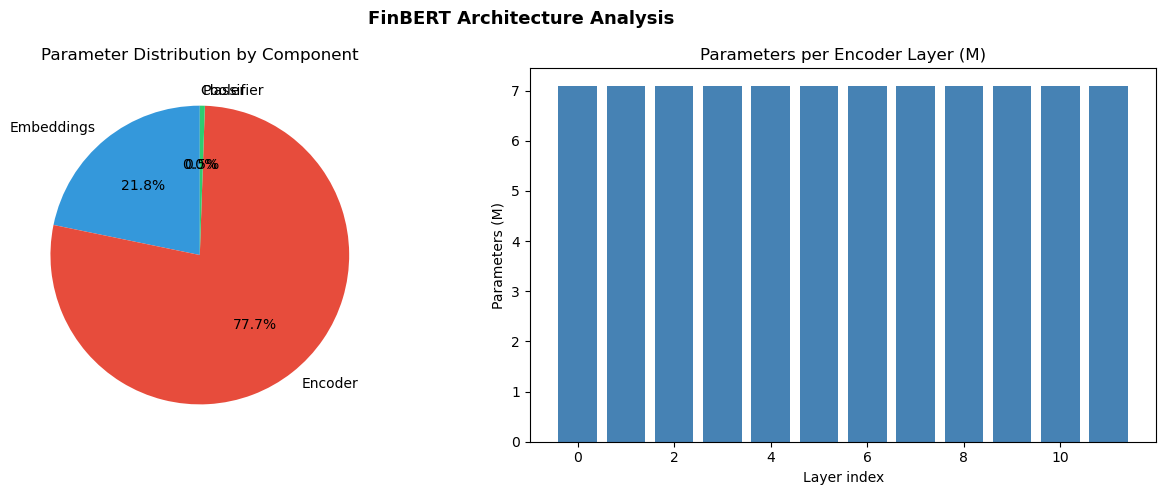

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Param breakdown pie
axes[0].pie(
    list(components.values()),
    labels=list(components.keys()),
    autopct='%1.1f%%', startangle=90,
    colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
)
axes[0].set_title('Parameter Distribution by Component')

# Per-layer parameter count
layer_params = [
    sum(p.numel() for p in layer.parameters())
    for layer in model.bert.encoder.layer
]
axes[1].bar(range(len(layer_params)), [p / 1e6 for p in layer_params], color='steelblue')
axes[1].set_title('Parameters per Encoder Layer (M)')
axes[1].set_xlabel('Layer index')
axes[1].set_ylabel('Parameters (M)')

plt.suptitle('FinBERT Architecture Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'architecture_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7 – Save baseline results & data splits

In [11]:
# Save benchmark results (used for comparison in later notebooks)
baseline_save = {k: v for k, v in baseline.items() if k != 'predictions'}
with open(os.path.join(BASE_DIR, 'baseline_results.json'), 'w') as f:
    json.dump(baseline_save, f, indent=2)

# Save data splits so all notebooks use identical test sets
splits = {
    'train_texts':  train_texts,
    'train_labels': train_labels,
    'test_texts':   test_texts,
    'test_labels':  test_labels,
    'label_remap':  LABEL_REMAP,
    'id2label':     model.config.id2label,
}
with open(os.path.join(BASE_DIR, 'data_splits.pkl'), 'wb') as f:
    pickle.dump(splits, f)

print('Saved', os.path.join(BASE_DIR, 'baseline_results.json'))
print('Saved', os.path.join(BASE_DIR, 'data_splits.pkl'))
print('\nBaseline summary:')
print('  Accuracy       : {:.2f}%'.format(baseline_save['accuracy'] * 100))
print('  Weighted F1    : {:.4f}'.format(baseline_save['f1_weighted']))
print('  Parameters     : {}M'.format(baseline_save['params_M']))
print('  Model size     : {}MB'.format(baseline_save['size_mb']))
print('  Inference speed: {}ms/sample'.format(baseline_save['ms_per_sample']))

Saved /Users/adebanjiadelowo/Documents/GitHub/Large-Language-Model-Notebooks-Course/P3-CustomFinancialLLM/baseline_results.json
Saved /Users/adebanjiadelowo/Documents/GitHub/Large-Language-Model-Notebooks-Course/P3-CustomFinancialLLM/data_splits.pkl

Baseline summary:
  Accuracy       : 97.57%
  Weighted F1    : 0.9761
  Parameters     : 109.48M
  Model size     : 417.67MB
  Inference speed: 20.331ms/sample


## Summary

We have established a complete baseline for FinBERT on the financial sentiment task.
These numbers are the target to beat (or at least maintain) after compression.

**Next step →** [P3_2_Model_Pruning.ipynb](P3_2_Model_Pruning.ipynb) applies attention-head
pruning and layer dropping to reduce the model's size and inference cost.